# Классификация: превышение значением SI медианного уровня

В данном ноутбуке решается задача бинарной классификации.

**Цель** - предсказать, превышает ли значение SI медианное значение выборки.

Параметр SI является расчетным показателем и связан с соотношением CC50 и IC50. Более высокий SI означает более выгодное сочетание эффективности и токсичности соединения.

Так как SI рассчитывается на основе IC50 и CC50, эти параметры не используются в качестве признаков при обучении модели, чтобы избежать утечки данных

## 1. Импорт библиотек и загрузка данных

In [ ]:
# Импорт
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import re

# Загрузка данных
df = pd.read_csv('cleaned_data.csv')
print("Размер датасета:", df.shape)

df.head()

Размер датасета: (1001, 78)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,...,fr_para_hydroxylation,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_pyridine,fr_sulfide,fr_sulfone,fr_term_acetylene,fr_thiocyan,fr_urea
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0,...,0,0,0,0,0,0,0,0,0,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0,...,0,0,0,0,0,0,0,0,0,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0,...,0,0,0,0,0,0,0,0,0,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0,...,0,0,0,0,0,0,0,0,0,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Подготовка данных

Для классификации используется бинарный признак: превышает ли SI медианное значение.

In [ ]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
X = df.drop(columns=targets, errors='ignore')
y_raw = df['SI']

# Создаем бинарный таргет
threshold = y_raw.median()
y_bin = (y_raw > threshold).astype(int)

print(f'Медианное значение SI - {threshold}\n')

print('Пропорция распределения:')
y_bin.value_counts(normalize=True)

Медианное значение SI - 3.846153846153846

Пропорция распределения:


,proportion
SI,
0,0.5005
1,0.4995


Классы получились примерно сбалансированными, так как порог выбран по медиане. Это позволяет использовать accuracy вместе с precision, recall, F1 и ROC-AUC.

## 3. Разделение на train и test

In [ ]:
# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Масштабирование
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in df.columns]
    return df

X_train_scaled = clean_column_names(X_train_scaled)
X_test_scaled = clean_column_names(X_test_scaled)

print(f"Размерность X_train: {X_train_scaled.shape}")

Размерность X_train: (800, 75)


## 4. Обучение моделей
Для решения задачи сравним несколько типов моделей:

- логистическую регрессию
- метод ближайших соседей
- решающее дерево
- ансамбли деревьев
- бустинговые модели

Это позволит понять, какие алгоритмы лучше подходят для разделения соединений по уровню SI.

In [ ]:
# Базовое сравнение моделей (без настройки)
models = {
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # predict_proba есть не у всех моделей
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc = 0.0

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': roc})

res_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
print("\nСравнение моделей без настройки:")
display(res_df)


Сравнение моделей без настройки:


,Model,Accuracy,F1,ROC-AUC
0,KNN,0.671642,0.682692,0.733861
6,GradientBoosting,0.636816,0.621762,0.682327
3,RandomForest,0.636816,0.617801,0.666535
2,LogisticRegression,0.646766,0.616216,0.649257
4,ExtraTrees,0.621891,0.616162,0.655446
7,LightGBM,0.621891,0.612245,0.646782
5,XGBoost,0.606965,0.594872,0.650743
1,DecisionTree,0.562189,0.568627,0.552079


Наилучший результат по F1 показали `GradientBoostingClassifier` и `KNeighborsClassifier`.

Выполним подбор гиперпараметров для наиболее перспективных алгоритмов. В качестве основной метрики используется `F1`, так как она учитывает баланс между `precision` и `recall`.

## 5. Подбор гиперпараметров

### GradientBoosting

In [ ]:
# Настройка GradientBoosting
gbc = GradientBoostingClassifier(random_state=42)

param_grid_gbc = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_leaf': [1, 2],
}

grid_gbc = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid_gbc,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_gbc.fit(X_train_scaled, y_train)

best_gbc_model = grid_gbc.best_estimator_
print("\nЛучшие параметры GBC:", grid_gbc.best_params_)
print(f"Лучшая F1 на кросс-валидации: {grid_gbc.best_score_:.4f}")

# Оценка на тесте
y_pred_gbc = best_gbc_model.predict(X_test_scaled)
y_prob_gbc = best_gbc_model.predict_proba(X_test_scaled)[:, 1]

acc_gbc = accuracy_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_gbc = roc_auc_score(y_test, y_prob_gbc)

print(f"\nРезультаты GradientBoosting на тесте:")
print(f"Accuracy: {acc_gbc:.4f}")
print(f"F1-score: {f1_gbc:.4f}")
print(f"ROC-AUC:  {roc_gbc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gbc))

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Лучшие параметры GBC: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Лучшая F1 на кросс-валидации: 0.6625

Результаты GradientBoosting на тесте:
Accuracy: 0.6517
F1-score: 0.6354
ROC-AUC:  0.6967

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.69      0.67       101
           1       0.66      0.61      0.64       100

    accuracy                           0.65       201
   macro avg       0.65      0.65      0.65       201
weighted avg       0.65      0.65      0.65       201



- Модель демонстрирует умеренное качество (F1 = 0.66).
- Модель лучше справляется с классом 0 (выше полнота — 0.69).
ROC-AUC около 0.7, что говорит о наличии ранжирующей способности.
- Низкая полнота (Recall = 0.61) для класса 1  — модель пропускает почти 39% объектов этого класса.
- Общая точность около 65%.

### KNeighborsClassifier

In [ ]:
# Настройка KNN
knn_model = KNeighborsClassifier(
    n_jobs=-1,
    p=2
)

# Сетка параметров для KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train_scaled, y_train)

best_knn_model = grid_knn.best_estimator_
print("\nЛучшие параметры KNN:", grid_knn.best_params_)
print(f"Лучшая F1 на кросс-валидации: {grid_knn.best_score_:.4f}")

# Оценка на тесте
y_pred_knn = best_knn_model.predict(X_test_scaled)
y_prob_knn = best_knn_model.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_knn = roc_auc_score(y_test, y_prob_knn)

print(f"\nРезультаты KNN на тесте:")
print(f"Accuracy: {acc_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
print(f"ROC-AUC:  {roc_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Лучшие параметры KNN: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Лучшая F1 на кросс-валидации: 0.6614

Результаты KNN на тесте:
Accuracy: 0.6965
F1-score: 0.6904
ROC-AUC:  0.7604

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       101
           1       0.70      0.68      0.69       100

    accuracy                           0.70       201
   macro avg       0.70      0.70      0.70       201
weighted avg       0.70      0.70      0.70       201



- Модель демонстрирует хорошее качество (F1 = 0.70), что лучше, чем у GradientBoosting.
- Хороший ROC-AUC (0.76) — модель хорошо ранжирует объекты.
- Сравнимая полнота (Recall) для класса 0 и 1 (около 0,7)
- KNN явно лучше GradientBoosting.

## Выбираем лучшую модель

In [ ]:
# Выбираем лучшую модель
if f1_knn>= f1_gbc:
    best_final_model = best_knn_model
    best_final_name = "KNeighborsClassifier"
    y_pred_final = y_pred_knn
else:
    best_final_model = best_gbc_model
    best_final_name = "GradientBoosting"
    y_pred_final = y_pred_gbc

print(f'Лучшая модель - {best_final_name}')

Лучшая модель - KNeighborsClassifier


- После подбора гиперпараметров лучшей моделью стала KNeighborsClassifier.

## Матрица ошибок (Confusion Matrix) и ROC-кривая

Матрица ошибок показывает, сколько объектов каждого класса модель классифицировала правильно и неправильно

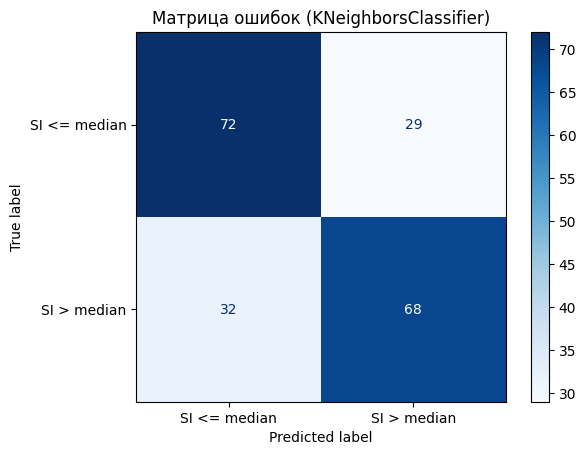

<Figure size 800x600 with 0 Axes>

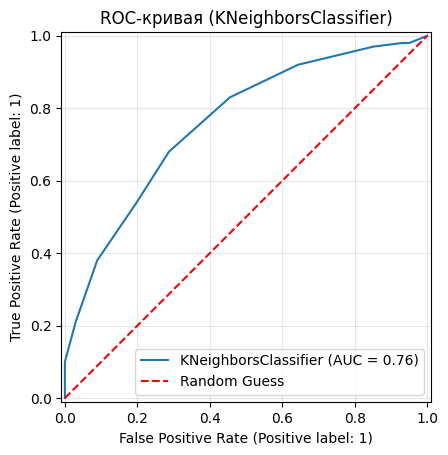

In [ ]:
# Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SI <= median", "SI > median"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Матрица ошибок ({best_final_name})")
plt.grid(False)
plt.show()

# ROC-кривая
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    best_final_model,
    X_test_scaled,  # Важно: используем масштабированные данные!
    y_test,
    name=best_final_name
)
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random Guess")
plt.title(f"ROC-кривая ({best_final_name})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Матрица ошибок показывает, что модель достаточно хорошо разделяет соединения по значению SI относительно медианы. Модель правильно классифицировала 72 объекта класса `SI <= median` и 68 объектов класса `SI > median`.

- Модель допустила 29 ложноположительных ошибок и 32 ложноотрицательных ошибок.

- ROC-кривая показывает, что модель хорошо отделяет соединения с SI выше медианы от остальных. Значение AUC составляет около 0.76, что заметно выше случайного угадывания 0.5.

- В целом модель сбалансирована. Она одинаково находит классы 1 и 0

## Выводы

- В рамках задачи построена модель бинарной классификации для определения, превышает ли SI медианное значение.
- Целевую переменную сформировали через медиану — это обеспечило сбалансированность классов и позволило корректно использовать метрики accuracy, F1 и ROC‑AUC.
- На этапе сравнения лучших результатов достиг K-Nearest Neighbors. Его показатели на тестовой выборке: accuracy = 0.70, F1 = 0.69, ROC‑AUC = 0.76.
- Матрица ошибок показывает, что модель достаточно хорошо разделяет соединения по значению SI относительно медианы. Модель правильно классифицировала 72 объекта класса `SI <= median` и 68 объектов класса `SI > median`.
- **Результат существенно лучше случайного угадывания.**